# BOREAS Velocity Visualization

This notebook visualizes the linear and angular velocities of a sequence from the BOREAS dataset. It plots each velocity component (vx, vy, vz for linear; wx, wy, wz for angular) separately in a 3x2 figure layout.

In [1]:
import os
import sys

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.dataset.utils import LidarOdometryWrapper

In [3]:
# Initialize the LidarOdometryWrapper
# This automatically loads the dataset and applies rotation around z-axis by default
wrapper = LidarOdometryWrapper(seq_idx=0)

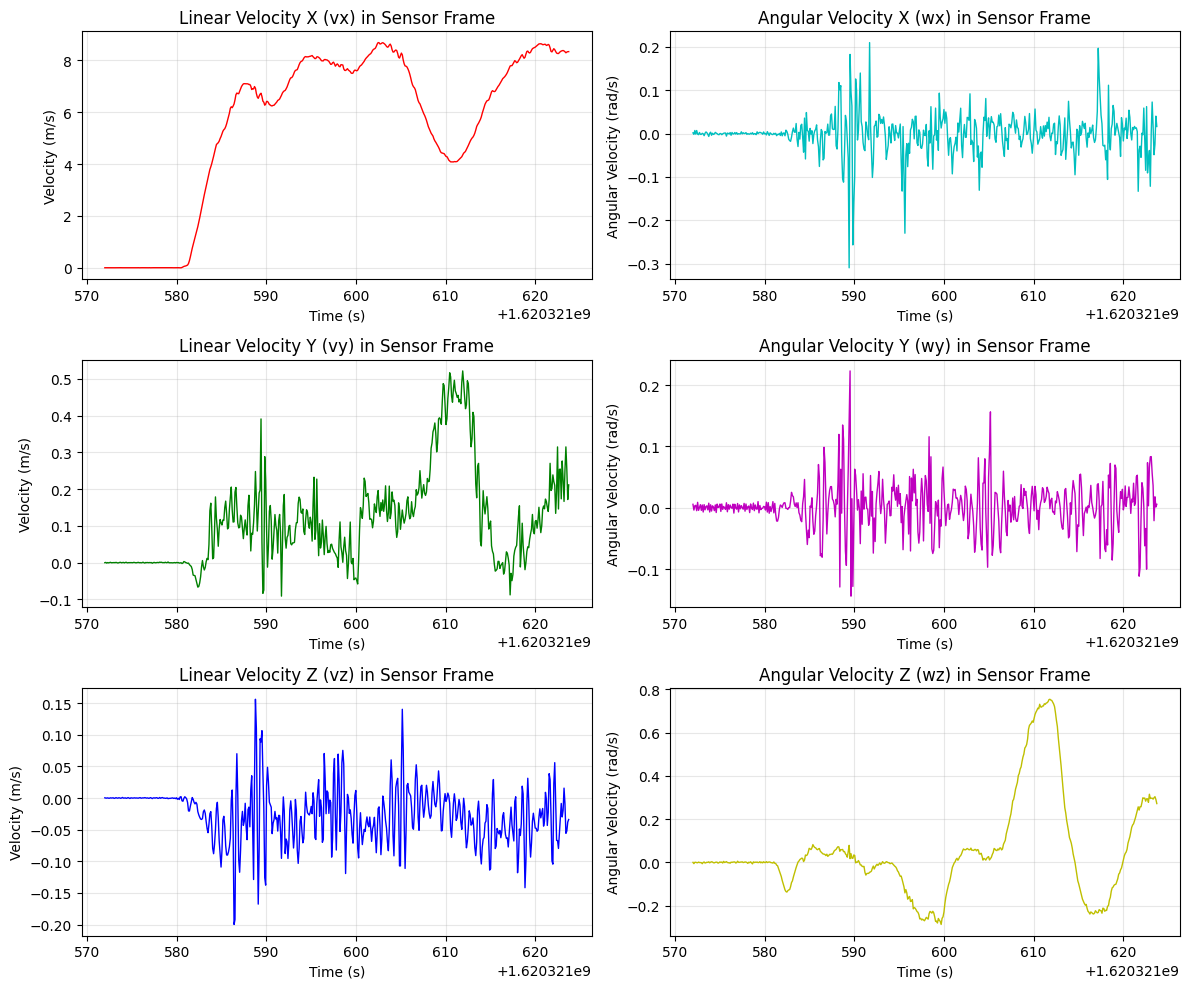

In [4]:
# Plot velocities of the first 500 frames
N_FRAMES = 500

# Initialize lists to store velocity data
vx_data = []
vy_data = []
vz_data = []
wx_data = []
wy_data = []
wz_data = []
t_data = []

# Iterate through frames using the wrapper
for i in range(N_FRAMES):
    # Get rotated velocities directly from the wrapper
    velocities = wrapper.get_velocities(i)
    
    vx_data.append(velocities[0])
    vy_data.append(velocities[1])
    vz_data.append(velocities[2])
    wx_data.append(velocities[3])
    wy_data.append(velocities[4])
    wz_data.append(velocities[5])
    
    # Get timestamp from the lidar frame
    lidar_frame = wrapper.seq.get_lidar(i)
    t_data.append(lidar_frame.timestamp)
    lidar_frame.unload_data()

# Create 3x2 figure layout
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# First row: vx and wx
axes[0, 0].plot(t_data, vx_data, "r-", linewidth=1)
axes[0, 0].set_title("Linear Velocity X (vx) in Sensor Frame")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Velocity (m/s)")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_data, wx_data, "c-", linewidth=1)
axes[0, 1].set_title("Angular Velocity X (wx) in Sensor Frame")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Angular Velocity (rad/s)")
axes[0, 1].grid(True, alpha=0.3)

# Second row: vy and wy
axes[1, 0].plot(t_data, vy_data, "g-", linewidth=1)
axes[1, 0].set_title("Linear Velocity Y (vy) in Sensor Frame")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Velocity (m/s)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_data, wy_data, "m-", linewidth=1)
axes[1, 1].set_title("Angular Velocity Y (wy) in Sensor Frame")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Angular Velocity (rad/s)")
axes[1, 1].grid(True, alpha=0.3)

# Third row: vz and wz
axes[2, 0].plot(t_data, vz_data, "b-", linewidth=1)
axes[2, 0].set_title("Linear Velocity Z (vz) in Sensor Frame")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Velocity (m/s)")
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(t_data, wz_data, "y-", linewidth=1)
axes[2, 1].set_title("Angular Velocity Z (wz) in Sensor Frame")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Angular Velocity (rad/s)")
axes[2, 1].grid(True, alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the figure
plt.show()